# Bibliotecas

In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import plotly.express as px

from statsmodels.tsa.stattools import adfuller
from matplotlib.pylab import rcParams

# Carregando os Dados

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/allefbcc/Pesquisa-TCC/refs/heads/main/S%C3%A9rie%20Temporal/dbp_2025.csv')

data['data'] = pd.to_datetime(data['data'], format='%Y-%m-%d')
data.set_index('data', inplace=True)

data['valores'] = pd.to_numeric(data['valores'], errors='coerce')
data = data.asfreq('MS')

data

,valores
data,
2003-08-01,8700.0
2003-09-01,8900.0
2003-10-01,8900.0
2003-11-01,9700.0
2003-12-01,16600.0
...,...
2025-08-01,78538.6
2025-09-01,78865.7
2025-10-01,78674.4


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 269 entries, 2003-08-01 to 2025-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   valores  267 non-null    float64
dtypes: float64(1)
memory usage: 4.2 KB


In [ ]:
data.isna().sum()

,0
valores,2


In [ ]:
data[data['valores'].isnull()]

,valores
data,
2004-07-01,NaN
2005-11-01,NaN


In [ ]:
data['valores'] = data['valores'].ffill()

In [ ]:
data.isna().sum()

,0
valores,0


In [ ]:
correcao1 = data['2004-06-01':'2004-07-01']
correcao1

,valores
data,
2004-06-01,9490.0
2004-07-01,9490.0


In [ ]:
correcao2 = data['2005-10-01':'2005-11-01']
correcao2

,valores
data,
2005-10-01,11830.0
2005-11-01,11830.0


In [ ]:
data.describe()

,valores
count,269.000000
mean,38919.809294
std,23743.160023
min,8630.000000
25%,19150.100000
50%,33564.000000
75%,53909.900000
max,112050.600000


# Gráficos Para Análise Temporal

## Gráfico De Histograma Da Série

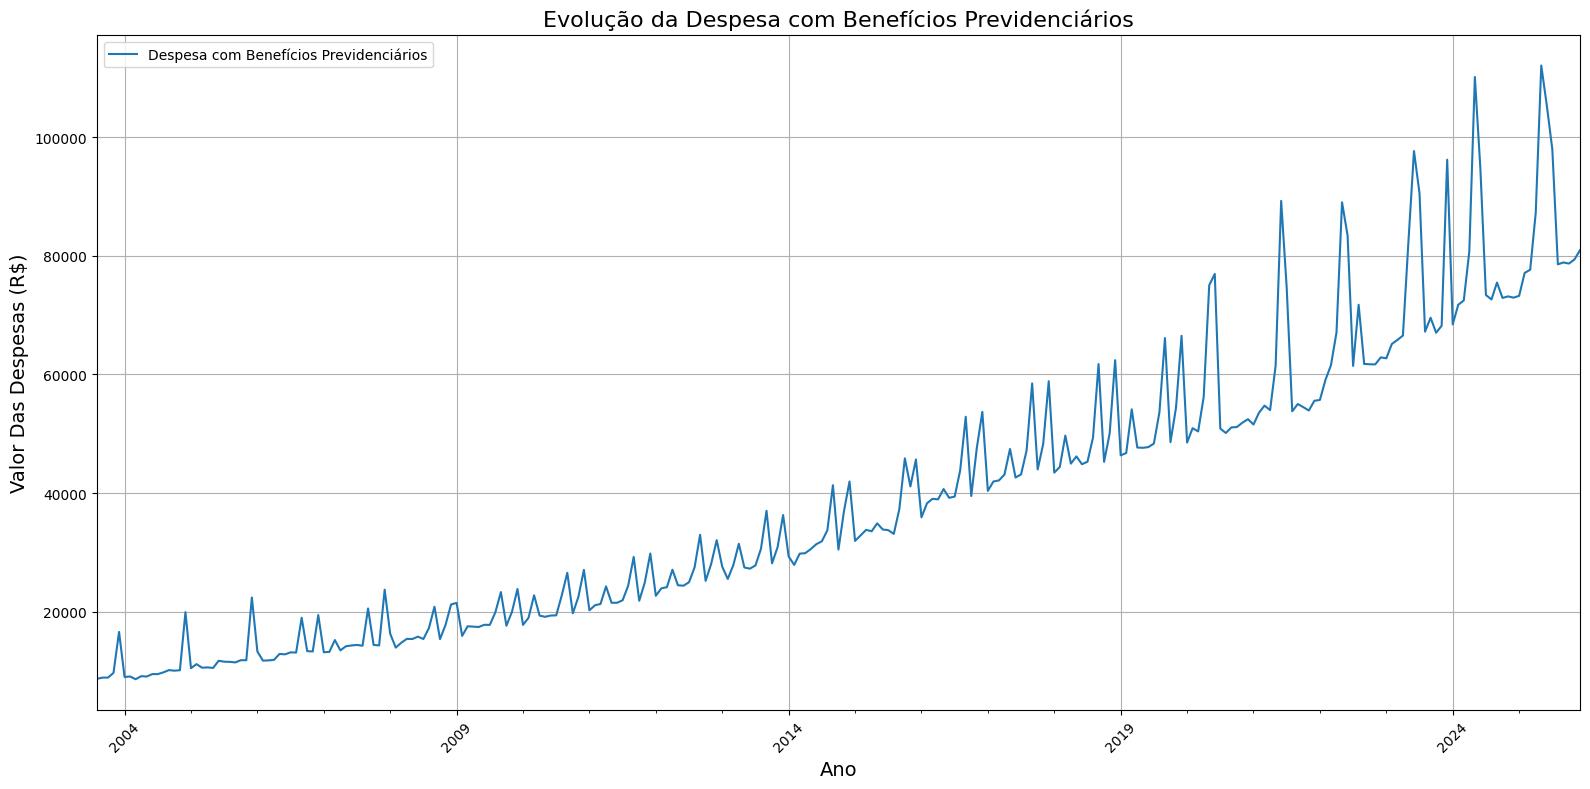

In [ ]:
plt.figure(figsize=(16, 8))


data['valores'].plot(label='Despesa com Benefícios Previdenciários')


plt.title('Evolução da Despesa com Benefícios Previdenciários', fontsize=16)
plt.xlabel('Ano', fontsize=14)
plt.ylabel('Valor Das Despesas (R$)', fontsize=14)


plt.legend(loc='upper left')


plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

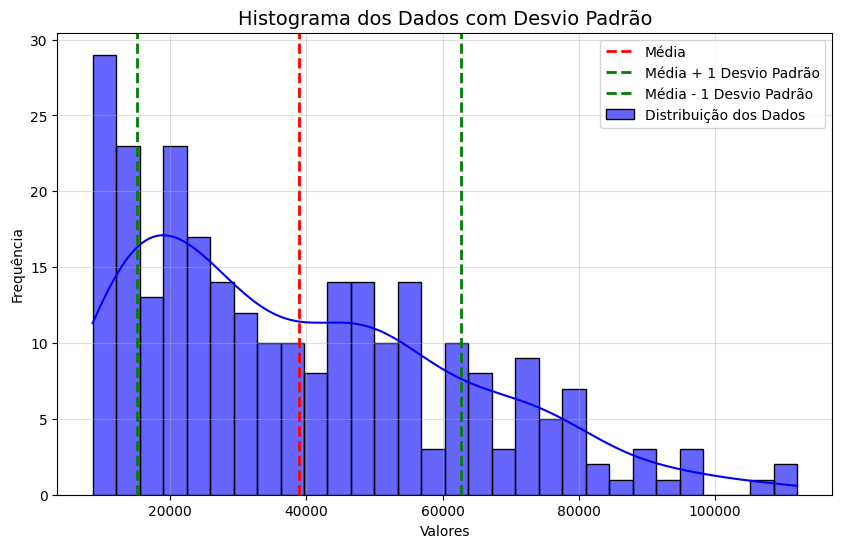

Desvio Padrão: 23743.16002279887


In [ ]:
std_dev = data['valores'].std()

plt.figure(figsize=(10, 6))
sns.histplot(data['valores'], kde=True, color='blue', bins=30, alpha=0.6, label='Distribuição dos Dados')
plt.axvline(data['valores'].mean(), color='red', linestyle='dashed', linewidth=2, label='Média')
plt.axvline(data['valores'].mean() + std_dev, color='green', linestyle='dashed', linewidth=2, label='Média + 1 Desvio Padrão')
plt.axvline(data['valores'].mean() - std_dev, color='green', linestyle='dashed', linewidth=2, label='Média - 1 Desvio Padrão')


plt.title('Histograma dos Dados com Desvio Padrão', fontsize=14)
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha=0.4)
plt.show()


print(f"Desvio Padrão: {std_dev}")

## Grafico De Decomposição Da Série

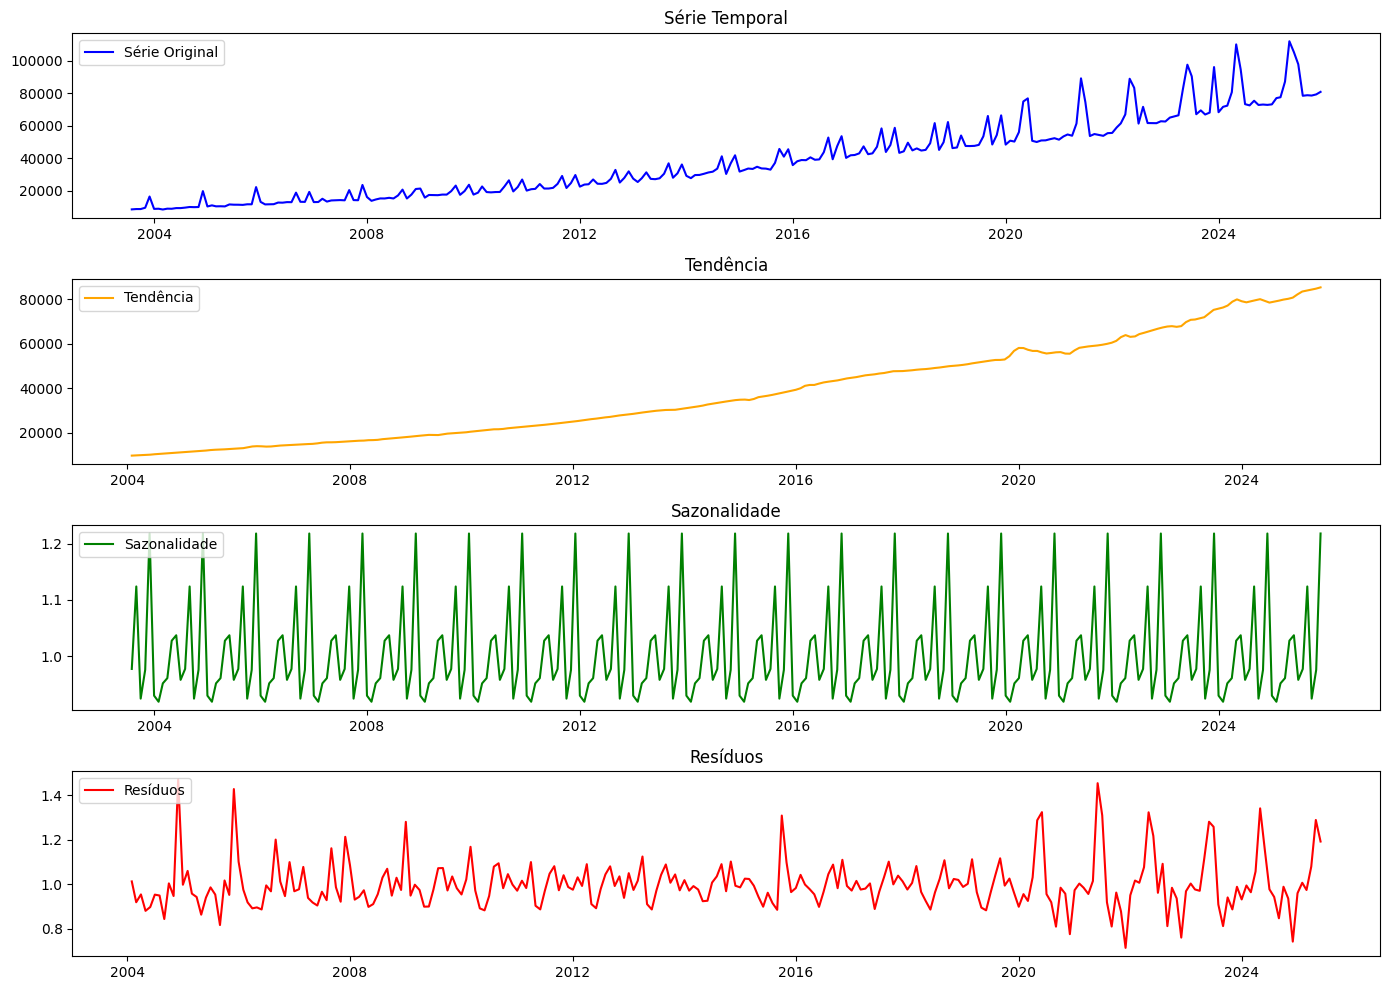

In [ ]:
decomposicao = seasonal_decompose(data['valores'], model='mul', period=12)


tendencia = decomposicao.trend
sazonalidade = decomposicao.seasonal
residuos = decomposicao.resid


plt.figure(figsize=(14, 10))


plt.subplot(4, 1, 1)
plt.plot(data['valores'], label='Série Original', color='blue')
plt.legend(loc='upper left')
plt.title('Série Temporal')


plt.subplot(4, 1, 2)
plt.plot(tendencia, label='Tendência', color='orange')
plt.legend(loc='upper left')
plt.title('Tendência')


plt.subplot(4, 1, 3)
plt.plot(sazonalidade, label='Sazonalidade', color='green')
plt.legend(loc='upper left')
plt.title('Sazonalidade')


plt.subplot(4, 1, 4)
plt.plot(residuos, label='Resíduos', color='red')
plt.legend(loc='upper left')
plt.title('Resíduos')


plt.tight_layout()
plt.show()

## Gráfico De Box Plot

In [ ]:
fig = px.box(data, y="valores")
fig.update_layout(
    title=dict(text="Boxplot das Despesas com Benefícios Previdenciários", x=0.5, font=dict(size=20)),
    yaxis_title="Valor (R$)"
)
fig.show()

# Avaliar Estacionariedade

## Teste ADF

Hipótese nula (H0): a série NÃO é estacionária.

Hipótese alternativa (H1): a série é estacionária.

Interpretação:

p-valor ≤ 0.05 → rejeita H0 → série estacionária.

p-valor > 0.05 → não rejeita H0 → série não estacionária (precisa diferenciar, detrendar ou transformar).

Os testes ADF fornecem os seguintes resultados: estatística de teste, valor p e valor crítico em intervalos de confiança de 1%, 5% e 10%.

In [ ]:
def testar_estacionariedade_adf(serie):
    resultado = adfuller(serie)
    print("Estatística de Teste ADF:", resultado[0])
    print("p-valor:", resultado[1])
    print("Valores Críticos:")
    for chave, valor in resultado[4].items():
        print(f"   {chave}: {valor}")
    if resultado[1] <= 0.05:
        print("A série é estacionária (H0 foi rejeitado).")
    else:
        print("A série NÃO é estacionária (H0 não foi rejeitado).")

print("\n--- Teste Dickey-Fuller ---")
testar_estacionariedade_adf(data)


--- Teste Dickey-Fuller ---
Estatística de Teste ADF: 2.8760466422018083
p-valor: 1.0
Valores Críticos:
   1%: -3.4565688966099373
   5%: -2.8730786194395455
   10%: -2.5729189953388762
A série NÃO é estacionária (H0 não foi rejeitado).


## Diferenciação

In [ ]:
data_diff = data.diff().dropna()

In [ ]:
testar_estacionariedade_adf(data_diff)

Estatística de Teste ADF: -5.3409249885918895
p-valor: 4.5021360987747174e-06
Valores Críticos:
   1%: -3.4566744514553016
   5%: -2.8731248767783426
   10%: -2.5729436702592023
A série é estacionária (H0 foi rejeitado).


In [ ]:
data_diff

,valores
data,
2003-09-01,200.0
2003-10-01,0.0
2003-11-01,800.0
2003-12-01,6900.0
2004-01-01,-7600.0
...,...
2025-08-01,-19360.4
2025-09-01,327.1
2025-10-01,-191.3


## Série Após a diferenciação

<Axes: xlabel='data'>

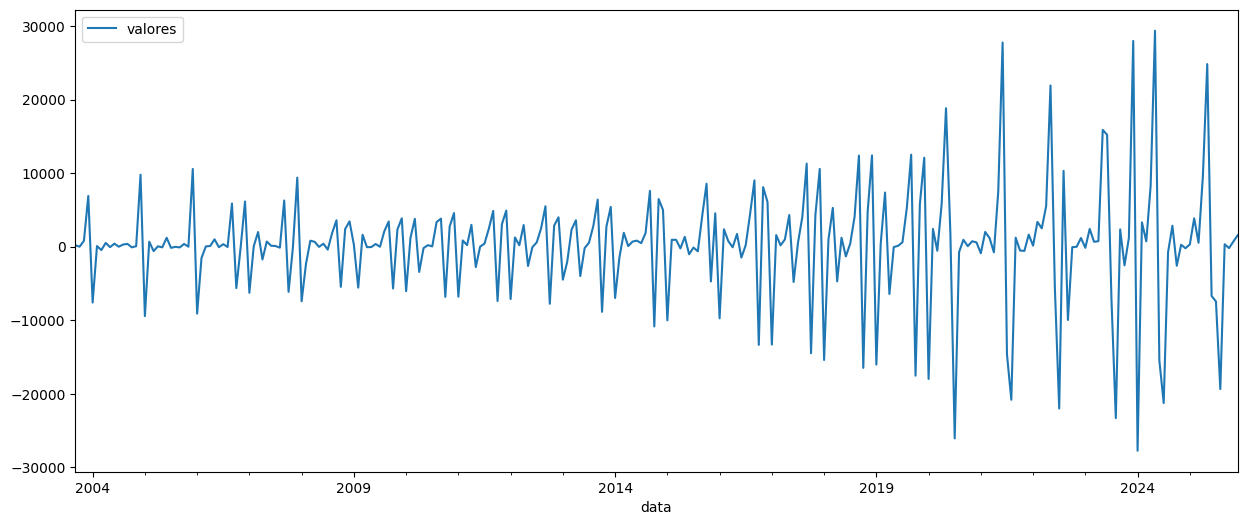

In [ ]:
rcParams['figure.figsize'] = 15, 6
data_diff.plot()

## Antes e Depois da Diferenciação

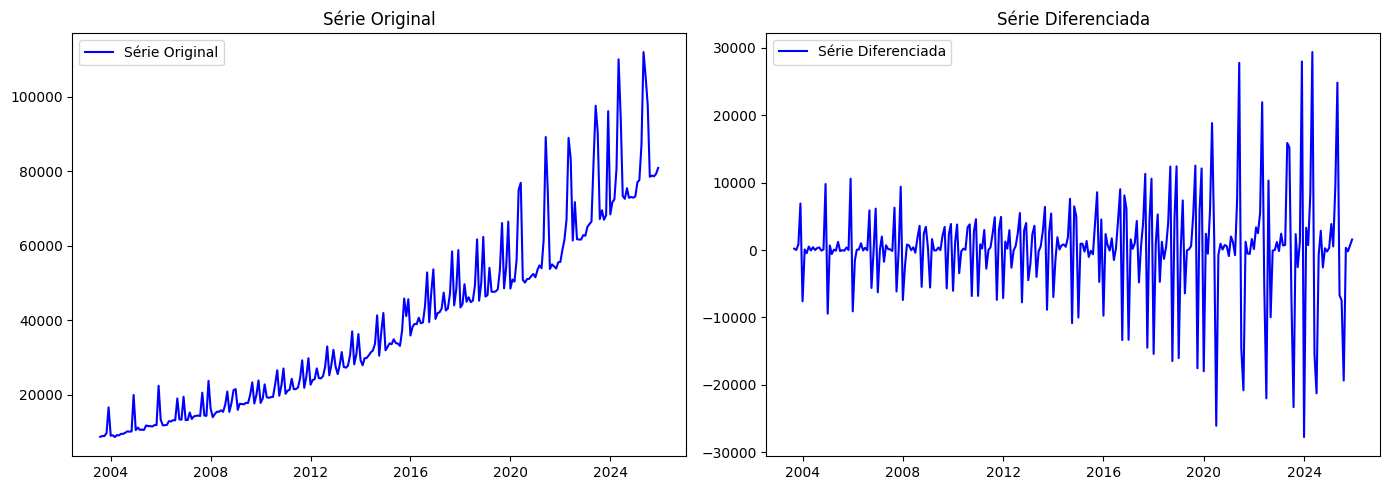

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(data, label="Série Original", color="blue")
plt.title("Série Original")
plt.legend()

plt.subplot(1,2,2)
plt.plot(data_diff, label="Série Diferenciada", color="blue")
plt.title("Série Diferenciada")
plt.legend()

plt.tight_layout()
plt.show()

# ACF e PACF Após a diferenciação

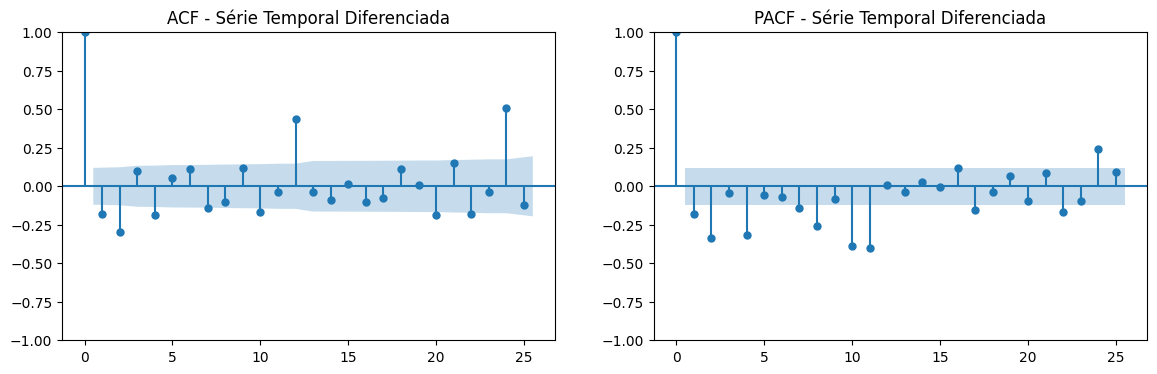

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(data_diff, lags=25, ax=ax[0])
plot_pacf(data_diff, lags=25, ax=ax[1])
ax[0].set_title("ACF - Série Temporal Diferenciada")
ax[1].set_title("PACF - Série Temporal Diferenciada")
plt.show()